Zonal Winds

This workbook analyses spatial and temporal wind patterns for comparison between models (ECHAM5 and CAM5) and observations (ERA Interim Reanalysis). The purpose is to validate a model to be used in the attribution (fingerprinting) analysis - does the model place the jet at the right location and simulation its poleward shift over time?

The results are saved to ~/figures/wind/.

In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import pandas as pd

import warnings
warnings.filterwarnings('ignore')

In [2]:
# Read in CAM5 ua 'eastward wind' data

direc = '~/../stoneda/data-for-laura/C20C/LBNL/CAM5-1-2-025degree/All-Hist/est1/v1-0/mon/atmos/ua/run'

ensemble_das = []
for run in ['001','002','003','004','005']:
    filepath = direc + run + '/'
    filename = 'ua_Amon_CAM5-1-2-025degree_All-Hist_est1_v1-0_run' + run + '_199601-201512.nc'

    ds = xr.open_dataset(filepath + filename)
    da = ds['ua'].sel(lat=slice(-90,0),lon=slice(160,200))

    ensemble_das.append(da)

ensemble_mean = np.mean([en.values for en in ensemble_das], 0)
coords_reference = ensemble_das[0]
ensemble_mean_da = xr.DataArray(ensemble_mean, 
                    dims={'time':coords_reference.time,'plev':coords_reference.plev,'lat':coords_reference.lat,'lon':coords_reference.lon},
                    coords={'time':coords_reference.time,'plev':coords_reference.plev,'lat':coords_reference.lat,'lon':coords_reference.lon})

CAM5_All_ua = ensemble_mean_da.resample(time='QS-DEC').mean()
CAM5_All_ua = CAM5_All_ua.mean('lon')
CAM5_All_ua = CAM5_All_ua.rename('eastward wind [m/s]')

In [3]:
# Read in ECHAM all-hist data

ECHAM_All_ua_ds = xr.open_dataset('~/data/netcdfs/ECHAM_All_ua.nc')

region = ECHAM_All_ua_ds['ua'].sel(lat=slice(0,-90),lon=slice(160,200))
seasonal = region.resample(time='QS-DEC').mean()
ECHAM_All_ua = seasonal.mean('lon')
ECHAM_All_ua = ECHAM_All_ua.rename('eastward wind [m/s]')

In [4]:
# Read in ECHAM nat data

ECHAM_Nat_ua_ds = xr.open_dataset('~/data/netcdfs/ECHAM_Nat_ua.nc')

region = ECHAM_Nat_ua_ds['ua'].sel(lat=slice(0,-90),lon=slice(160,200))
seasonal = region.resample(time='QS-DEC').mean()
ECHAM_Nat_ua = seasonal.mean('lon')
ECHAM_Nat_ua = ECHAM_Nat_ua.rename('eastward wind [m/s]')

In [2]:
# Read in ERA data
data = xr.open_dataset('~/data/netcdfs/ERA.nc')

# select expver=0001 (ERA5) data as opposed to expver=0005 (ERA5T; initial release) data
ERA5 = data.isel(expver=0)
seasonal = ERA5['u'].resample(time = 'QS-DEC').mean()
ERA5 = seasonal.mean('longitude')
ERA5 = ERA5.rename('eastward wind [m/s]')

FileNotFoundError: [Errno 2] No such file or directory: '/home/queenle/data/netcdfs/ERA.nc'

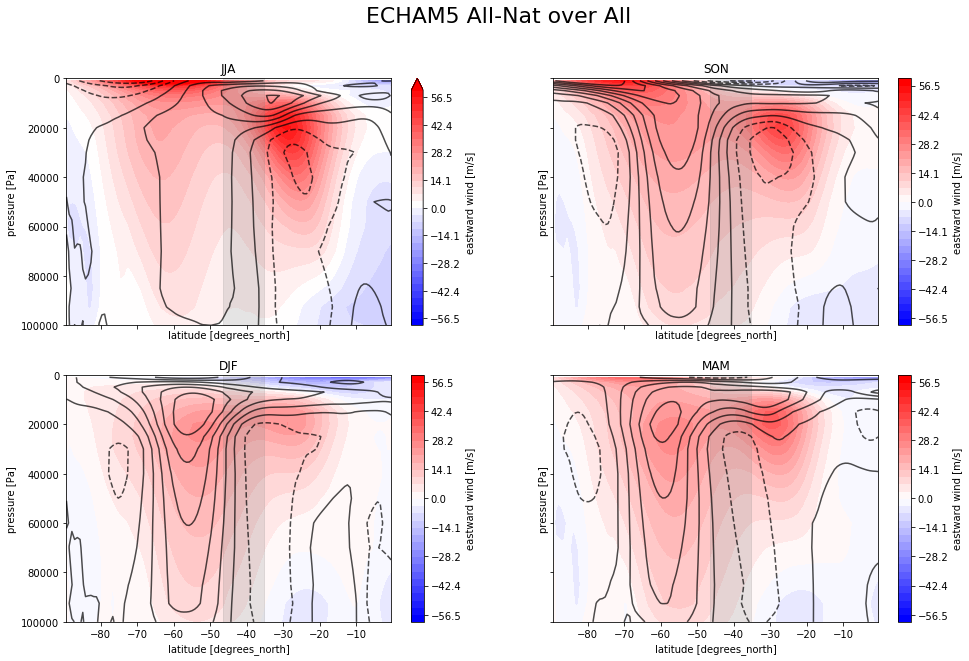

In [52]:
'''
For each season, plot average zonal wind 2010-2019 as function of lat and level (pressure).
Contour lines are the (all-nat) scenario and colored contours are the all-forcings scenario. 
'''

model = 'ECHAM5'
#model = 'CAM5'

model_data = [ECHAM_All_ua,ECHAM_Nat_ua]
#model_data = [CAM5_All_ua,CAM5_Nat_ua]

fig,axs = plt.subplots(2,2, figsize=(16,10), sharex=True,sharey=True)

seasons = ['JJA','SON','DJF','MAM']

i = 0
for ax in axs.flatten():
    ax.axvspan(-46.56, -35.23, alpha=0.2, color='grey')

    al = model_data[0].sel(time=model_data[0]['time.season']==seasons[i])
    al_present = al.isel(time=slice(-11,-1)).mean('time') 
    
    nat = model_data[1].sel(time=model_data[1]['time.season']==seasons[i])
    nat_present = nat.isel(time=slice(-11,-1)).mean('time') 
    
    diff = (al_present - nat_present)

    al_present.plot.contourf(ax=ax,add_colorbar=True,cmap='bwr',vmin=-60,vmax=60,levels=35)
    diff.plot.contour(ax=ax,add_colorbar=False,colors='black',alpha=.7,levels=15,vmin=-4,vmax=4)
        
    ax.set_title(seasons[i])
    
    i+=1 
    
plt.suptitle(model + ' All-Nat over All',fontsize=22)
plt.show()
#plt.savefig('~/figures/wind/' + model + 'seasonalmean_zonal_winds.png')

Text(0.5, 0.98, 'ERA present - past over past')

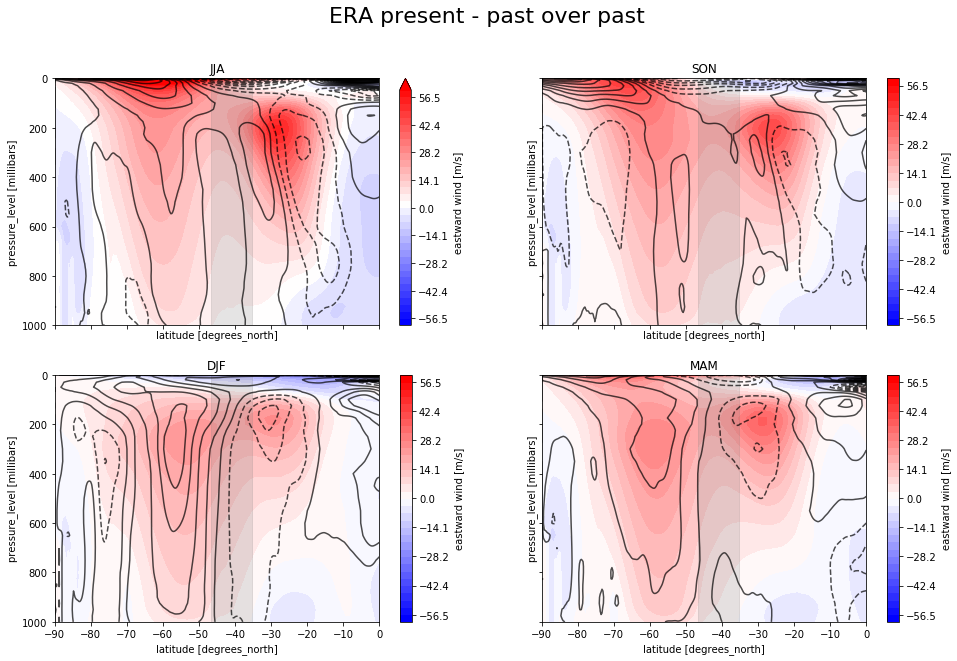

In [71]:
'''
For each season, plot average zonal wind as function of lat and level (pressure).
Contour lines are the (all-nat) scenario and colored contours are the all-forcings scenario. 
'''

#model = 'ECHAM5'
#model = 'CAM5'
model = 'ERA'

#model_data = ECHAM_All_ua
#model_data = CAM5_All_ua
model_data = ERA5

fig,axs = plt.subplots(2,2, figsize=(16,10), sharex=True,sharey=True)

seasons = ['JJA','SON','DJF','MAM']

i = 0
for ax in axs.flatten():
    ax.axvspan(-46.56, -35.23, alpha=0.2, color='grey')
    season = model_data.sel(time=model_data['time.season']==seasons[i])
    
    past = season.isel(time=slice(0,10)).mean('time')    
    present = season.isel(time=slice(-11,-1)).mean('time')

    diff = (present - past)
    data = diff.rename('zonal wind difference')

    
    past.plot.contourf(ax=ax,add_colorbar=True,cmap='bwr',vmin=-60,vmax=60,levels=35)
    
    cntr = data.plot.contour(ax=ax,add_colorbar=False,colors='black',alpha=.7,levels=25,vmin=-9,vmax=9)
        
    if model == 'ERA':
        ax.set_ylim(1000,0)
    else:
        ax.set_ylim(100000,0)
        
    ax.set_title(seasons[i])
    
    i += 1
    
plt.suptitle(model + ' present - past over past',fontsize=22)
#plt.savefig('~/figures/wind/' + model + 'presentpast_zonal_winds.png')

Text(0.5, 0.98, 'plev=850 surface wind')

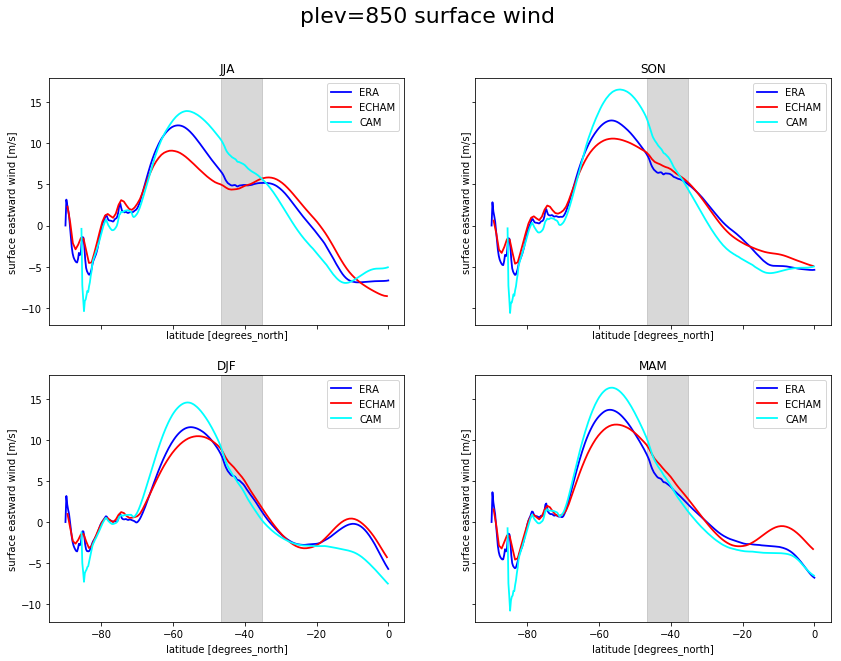

In [74]:
'''
Surface wind plot
'''

surface_ERA = ERA5.sel(level=850)
surface_ECHAM = ECHAM_All_ua.sel(plev=85000)
surface_CAM = CAM5_All_ua.sel(plev=85000)

fig,axs = plt.subplots(2,2,figsize=(14,10),sharex=True,sharey=True)

seasons = ['JJA','SON','DJF','MAM']

i = 0
for ax in axs.flatten():
    
    ax.axvspan(-46.56, -35.23, alpha=0.3, color='grey')
    
    season = surface_ERA.sel(time=surface_ERA['time.season']==seasons[i]).mean('time')
    season.plot(ax=ax,label='ERA',color='blue',linewidth=1.8)
    #print(seasons[i] + ' ' + str(season.where(season==season.max(),drop=True).squeeze().latitude.values))
    
    season = surface_ECHAM.sel(time=surface_ECHAM['time.season']==seasons[i]).mean('time')
    season.plot(ax=ax,label='ECHAM',color='red',linewidth=1.8)
  
    season = surface_CAM.sel(time=surface_CAM['time.season']==seasons[i]).mean('time')
    season.plot(ax=ax,label='CAM',color='cyan',linewidth=1.8)
    
    ax.set_title(seasons[i])
    ax.legend()
    ax.set_ylabel('surface eastward wind [m/s]')
    
    i += 1

plt.suptitle('plev=850 surface wind',fontsize=22)